# Modelo de agentes SEIRD

## Introdução

O modelo descrito por Weits e Dushoff (2015, https://www.nature.com/articles/srep08751) tem sua dinâmica descrita pelas seguintes equações diferenciais ordinárias (EDOs):

\begin{align}
     \frac{dS}{dt} &= -\frac{\beta_{I}SI}{N} - \frac{\beta_{D}SD}{N} \\
     \frac{dE}{dt} &= \frac{\beta_{I}SI}{N} + \frac{\beta_{D}SD}{N} - \frac{E}{T_{E}} \\
     \frac{dI}{dt} &= \frac{E}{T_{E}} - \frac{I}{T_{I}} \\
     \frac{dR}{dt} &= \frac{(1-f)I}{T_{I}} \\
     \frac{dD}{dt} &= \frac{fI}{T_{I}} - \frac{D}{T_{D}} \\
     N & = S+E+I+R
\end{align}

Onde a população está dividida entre suscetíveis ($S$), expostos ($E$), infectados ($I$, mas talvez seja uma boa ideia mudar para "infecciosos"), removidos ($R$) e mortos ($D$). A população total ($N$) não inclui mortos, apesar destes poderem infectar a população suscetível. Isso significa que valores normalizados, como $S/N$, podem crescer na medida em que $N$ diminui devido às mortes. Os parâmetros epidêmicos do modelo são a taxa de infecção através de infectados ($\beta_{I}$), a taxa de infecção através de mortos ($\beta_{D}$), o período de incubação ($T_{E}$), o período de infectividade dos vivos ($T_{I}$), o período de infectividade dos mortos ($T_{D}$), e $f$ é a taxa de letalidade.

No presente modelo baseado em agentes (MBA) estocástico, a mudança de estado de infecção dos agentes acontece a cada iteração da simulação com as seguintes probabilidades:

\begin{align}
     S \rightarrow E, \quad & p_{SE\_I} = \frac{\beta_{I} I}{N} \Delta t \\
     S \rightarrow E, \quad & p_{SE\_D} = \frac{\beta_{D} D}{N} \Delta t\\
     E \rightarrow I, \quad & p_{EI} = \frac{1}{T_{E}} \Delta t \\
     I \rightarrow R, \quad & p_{IR} = \frac{1-f}{T_{I}} \Delta t \\
     I \rightarrow D, \quad & p_{ID} = \frac{f}{T_{I}} \Delta t \\
     D \rightarrow \varnothing, \quad & p_{D} = \frac{1}{T_{D}} \Delta t
\end{align}

Existem dois caminhos para que os sucetíveis sejam infectados: pelo contato com a população infectada viva ($I$) ou morta ($D$). Na realidade, uma pessoa poderia ter contato tanto com infectados vivos quanto mortos, e o próprio artigo menciona isso. Em casos de duplo contato é difícil distinguir qual foi o contato determinante para a causar a infecção. 

Logo, optou-se por uma aplicação de um MBA que possibilitasse o contato duplo, mas ainda não distingue qual foi aquele que gerou a infecção. Isso é feito a partir de dois teste aleatórios para o mesmo grupo de sucetíveis, um teste para a infecção por infectados vivos e outra para mortos. Ao final de cada teste, verifica-se qual foi o tipo de infecção de cada agente $S$ que se tornou $I$.

Resolvendo numericamente as EDOs desses sistema a quantidade de sucetíveis que se tornam expostos é $\left(-\beta_{I}SI/N - \beta_{D}SD/N \right)dt$, tratando-se de uma soma simples e desconsiderando sobreposições de infecções cuasdas por $I$ e $D$. Essa diferença entre o método MBA e EDOs é conciente e pode ser revista no futuro.

Outro ponto que merece atenção é a transição de agentes $I$ para $R$ e $D$. Da mesma forma é feito um teste com um sorteio aleatório, e a mudança de grupo é avaliada com uma espécie de _tower sampling_. Primeiro se avalia quantos valores aleatórios então são menores ou iguais a $p_{IR} + p_{ID}$ e todos estes tornam-se $D$. Depois verifica-se quais são menores que $p_{IR}$, e modificam-se para $R$.

Ainda, Cardoso e Gonçalves (2021, https://iopscience.iop.org/article/10.1209/0295-5075/133/58001/pdf) apontam que, em um modelo SEIR (desconsidera mortos), a taxa de infecção é dada pelo produto $\beta = \mathcal{C}p$, onde $p$ é a probabilidade de transmissão e $\mathcal{C}$ é a taxa de contato _per capita_. Segundo os autores, $\mathcal{C}$ também guarda uma relação de proporcionalidade com o grau de interação social ($k$), mas no momento isto não será considerado por enquanto porque tal grau de interação social está mais associado à densidade populacional sem diferenciar os tipos de interação possíveis na população. No modelo SEIRD, a dois tipos distintos de interação que levam à infecção, aquela com agentes vivos e outro com agentes mortos, então deve-se pensar nas diferenças de cada tipo de contato.

O modelo considerando o isolamento de infectados a uma taxa $\alpha$, e que não infectam após sua morte, é dado da seguinte forma
\begin{align}
     \frac{dS}{dt} &= -\frac{\beta_{I}SI}{N} - \frac{\beta_{D}SD}{N} \\
     \frac{dE}{dt} &= \frac{\beta_{I}SI}{N} + \frac{\beta_{D}SD}{N} - \frac{E}{T_{E}} \\
     \frac{dI}{dt} &= \frac{E}{T_{E}} - \alpha I - \frac{I}{T_{I}} \\
     \frac{dII}{dt} &= \alpha I - \frac{II}{T_{I}} \\
     \frac{dR}{dt} &= \frac{(1-f)I}{T_{I}} + \frac{(1-f)II}{T_{I}} \\
     \frac{dD}{dt} &= \frac{fI}{T_{I}} - \frac{D}{T_{D}} \\
     N & = S+E+I+R
\end{align}

Com as seguintes probabilidades

\begin{align}
     S \rightarrow E, \quad & p_{SE\_I} = \frac{\beta_{I} I}{N} \Delta t \\
     S \rightarrow E, \quad & p_{SE\_D} = \frac{\beta_{D} D}{N} \Delta t\\
     E \rightarrow I, \quad & p_{EI} = \frac{1}{T_{E}} \Delta t \\
     I \rightarrow II, \quad & p_{III} = \alpha \Delta t \\
     I \rightarrow R, \quad & p_{IR} = \frac{1-f}{T_{I}} \Delta t \\
     I \rightarrow D, \quad & p_{ID} = \frac{f}{T_{I}} \Delta t \\
     II \rightarrow R, \quad & p_{IR} = \frac{1-f}{T_{I}} \Delta t \\
     II \rightarrow \varnothing, \quad & p_{II} = \frac{1}{T_{D}} \Delta t \\
     D \rightarrow \varnothing, \quad & p_{D} = \frac{1}{T_{D}} \Delta t
\end{align}

## Importando pacores e definindo objetos e funções

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import agent_based_model as abm

In [4]:
# Função para fazer várias simulações de uma vez só
# 'params' é um array 2D com combinações de parâmetros epidêmicos
def func_sim_agents(model, init_conditions, params, dt, tf):

    N_states = len(init_conditions)
    N_sims = len(params)
    N_steps = int(tf/dt + 1)

    series = np.empty((N_states, N_sims, N_steps), dtype=np.float64)

    for i in range(N_sims):

        match model:

            case 'SEIRD':
                epidemic = abm.SEIRD(*init_conditions, *params[i][:-1], dt)

            case 'SEIRD_numba':
                epidemic = abm.SEIRD_numba(*init_conditions, *params[i][:-1], dt)

            case 'SEIRD_II':
                epidemic = abm.SEIRD_II(*init_conditions, *params[i][:-1], dt)

            case 'SEIRD_II_numba':
                epidemic = abm.SEIRD_II_numba(*init_conditions, *params[i][:-1], dt)

        epidemic.step(int(tf/dt))

        # Coletar arrays da simulação e adicionar na lista
        all_series = epidemic.get_series()

        series[:,i,:] = all_series[1:N_states+1]

    return params, *series

# Função para salvar simulações de várias epidemias
def save_sim(sim, name, file_format):

    match file_format:
        case 'npz':
            np.savez_compressed(name,
                    parameters = sim[0], susceptible = sim[1], exposed = sim[2],
                    infected = sim[3], removed = sim[4], dead = sim[5])

        case 'csv':
            df = pd.DataFrame({'beta_I': sim[0][:,0], 'beta_D': sim[0][:,1], 't_E': sim[0][:,2], 't_I': sim[0][:,3],
                               't_D': sim[0][:,4], 'f': sim[0][:,5], 'n_sample': sim[0][:,6],
                               'suceptible': sim[1].tolist(), 'exposed': sim[2].tolist(), 'infected': sim[3].tolist(),
                               'removed': sim[4].tolist(), 'dead': sim[5].tolist()})
            df.to_csv('{}.csv'.format(name), index=False)

def modelo_seird(S0, E0, I0, R0, D0, beta_I, beta_D, t_E, t_I, t_D, f, tf=50, dt=0.1):
    tempos = np.arange(0, tf, dt)


    S = np.zeros(len(tempos))
    E = np.zeros(len(tempos))
    I = np.zeros(len(tempos))
    R = np.zeros(len(tempos))
    D = np.zeros(len(tempos))

    S[0], E[0], I[0], R[0] , D[0]= S0, E0, I0, R0, D0

    for i in range(len(tempos) - 1):

        N = S[i] + E[i] + I[i] + R[i]

        ds = -(beta_I * S[i] * I[i]) / N - (beta_D * S[i] * D[i]) / N
        de = (beta_I * S[i] * I[i]) / N + (beta_D * S[i]) * D[i] / N - (E[i] / t_E)
        di = (E[i] / t_E) - (I[i] / t_I)
        dr = (1 - f) * (I[i] / t_I)
        dd = (f * I[i] / t_I) - (D[i] / t_D)

        S[i+1] = S[i] + ds *dt
        E[i+1] = E[i] + de *dt
        I[i+1] = I[i] + di *dt
        R[i+1] = R[i] + dr *dt
        D[i+1] = D[i] + dd *dt

    return tempos, S, E, I, R, D

def modelo_seird_ii(S0, E0, I0, II0, R0, D0, beta_I, beta_II, beta_D, t_E, t_I, alpha, t_D, f, tf=50, dt=0.1):
    tempos = np.arange(0, tf, dt)


    S = np.zeros(len(tempos))
    E = np.zeros(len(tempos))
    I = np.zeros(len(tempos))
    II = np.zeros(len(tempos))
    R = np.zeros(len(tempos))
    D = np.zeros(len(tempos))

    S[0], E[0], I[0], II[0], R[0] , D[0]= S0, E0, I0, II0, R0, D0

    for i in range(len(tempos) - 1):

        N = S[i] + E[i] + I[i] + II[i]+ R[i]

        ds = -(beta_I * S[i] * I[i]) / N - (beta_II * S[i] * II[i]) / N - (beta_D * S[i] * D[i]) / N
        de = (beta_I * S[i] * I[i]) / N + (beta_II * S[i] * II[i]) / N + (beta_D * S[i]) * D[i] / N - (E[i] / t_E)
        di = (E[i] / t_E) - (I[i] / t_I) - (alpha * I[i])
        dii = (alpha * I[i]) - (II[i] / t_I)
        dr = (1 - f) * ((I[i] + II[i])/ t_I)
        dd = (f * I[i] / t_I) - (D[i] / t_D)

        S[i+1] = S[i] + ds *dt
        E[i+1] = E[i] + de *dt
        I[i+1] = I[i] + di *dt
        II[i+1] = II[i] + dii *dt
        R[i+1] = R[i] + dr *dt
        D[i+1] = D[i] + dd *dt

    return tempos, S, E, I, II, R, D



## Simulando uma epidemia

In [9]:
# Condições iniciais
N, S_i = 100_000, 99_990
I_i = 10
II_i, E_i, R_i, D_i = 0, 0, 0, 0

# Parâmetros epidêmicos
# Considerando que taxas de infecção são iguais às taxas de contato per capta 
# multiplicada pela probabilidade de infecção do contato (beta = c * p),
# consideramos que a doença tem um "p" fixo e "c" torna-se o que define "beta"
p = 0.01
c_I, c_II, c_D = 25, 3, 100
beta_I, beta_II, beta_D = p * c_I, p * c_II, p * c_D
T_E, T_I, T_D = 11, 6, 4
alpha, f = 0.2, 0.7

dt, tf = 0.1, 400

'''
# Condições iniciais avançadas no tempo
EDOs = modelo_seird(S_i, E_i, I_i, R_i, D_i, beta_I, beta_D, T_E, T_I, T_D, f, tf, dt)
new_initical_cond = [int(EDOs[i][-1]) for i in range(6)]
S_i, E_i, I_i, R_i, D_i = new_initical_cond[1:]
'''

# Criar sistema
epidemic = abm.SEIRD_II(S_i, E_i, I_i, II_i, R_i, D_i,
                beta_I, beta_II, beta_D, T_E, T_I, alpha, T_D, f, dt)

# Evoluir epidemia
epidemic.step(int(tf/dt))

# Coletar séries
epidemic_series = epidemic.get_series()

100%|██████████| 4000/4000 [00:04<00:00, 807.19it/s] 


Não infectado = [100000]


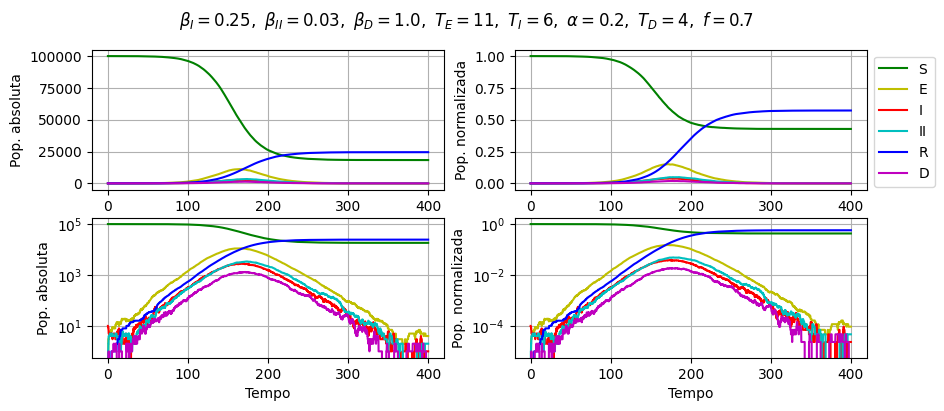

In [10]:
# Imprimir total de infecções de cada tipo
inf_type_dict = {0: 'S', 2: 'I', 3: 'II', 5: 'D', 7: 'I ou D'}
inf_type, inf_type_count = np.unique(epidemic.infection_type, return_counts=True)
for it in inf_type:
    if it == 0:
        print('Não infectado = {}'.format(inf_type_count[inf_type == it]))
    else:
        print('Infectados por {} = {}'.format(inf_type_dict[it], inf_type_count[inf_type == it]))

# Plotar séries temporais
labels = ['S', 'E', 'I', 'II', 'R', 'D']
colors = ['g', 'y', 'r', 'c', 'b', 'm']

fig, ax = plt.subplots(2,2, figsize=(10,4))

fig.suptitle(r'$\beta_{{I}} = {}, \ \beta_{{II}} = {}, \ \beta_{{D}} = {}, \ T_{{E}} = {}, \ T_{{I}} = {}, \ \alpha = {}, \ T_{{D}} = {}, \ f = {}$'.format(beta_I, beta_II, beta_D, T_E, T_I, alpha, T_D, f))

for i in range(6):
    ax[0,0].plot(epidemic_series[0], epidemic_series[i+1], 
                label=labels[i], c=colors[i])
    ax[0,1].plot(epidemic_series[0], epidemic_series[i+1]/epidemic_series[-1], 
                label=labels[i], c=colors[i])
    ax[1,0].plot(epidemic_series[0], epidemic_series[i+1], 
                label=labels[i], c=colors[i])
    ax[1,1].plot(epidemic_series[0], epidemic_series[i+1]/epidemic_series[-1], 
                label=labels[i], c=colors[i])

ax[0,0].set(ylabel = 'Pop. absoluta')
ax[1,0].set(ylabel = 'Pop. absoluta', xlabel = 'Tempo', yscale='log')
ax[0,1].set(ylabel = 'Pop. normalizada')
ax[1,1].set(ylabel = 'Pop. normalizada', xlabel = 'Tempo', yscale='log')

for a in (ax).flat:
    a.grid()

ax[0,1].legend(loc='upper left', bbox_to_anchor=(1, 1)) 
  

Comparar com resultados do método de Euler

[None]

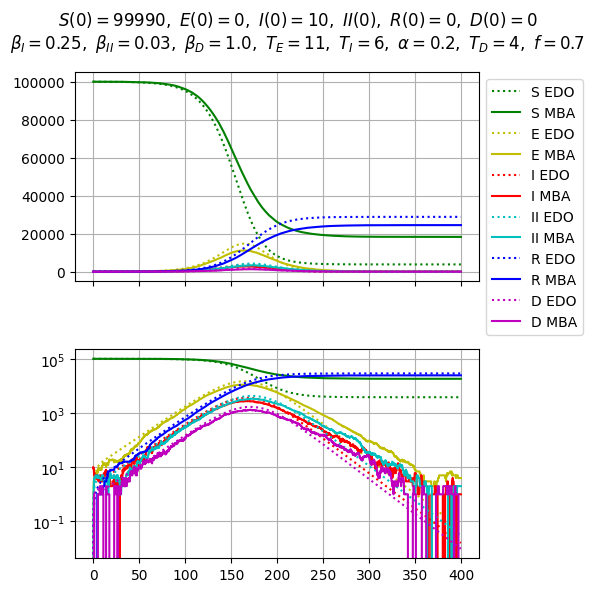

In [11]:
EDOs = modelo_seird_ii(S_i, E_i, I_i, II_i, R_i, D_i,
                        beta_I, beta_II, beta_D, T_E, T_I, alpha, T_D, f, tf, dt)
                        
labels = ['S', 'E', 'I', 'II', 'R', 'D']
colors = ['g', 'y', 'r', 'c', 'b', 'm']

fig, ax = plt.subplots(2,1, figsize=(6,6), sharex='col', layout='tight')

initial_conditions_label = r'$S(0) = {}, \ E(0) = {}, \ I(0) = {}, \ II(0), \ R(0) = {}, \ D(0) = {}$'.format(S_i, E_i, I_i, II_i, R_i, D_i)
parameters_label = r'$\beta_{{I}} = {}, \ \beta_{{II}} = {}, \ \beta_{{D}} = {}, \ T_{{E}} = {}, \ T_{{I}} = {}, \ \alpha = {}, \ T_{{D}} = {}, \ f = {}$'.format(beta_I, beta_II, beta_D, T_E, T_I, alpha, T_D, f)
fig.suptitle(initial_conditions_label+'\n'+ parameters_label)

for a in ax:
    for i in range(6):
        a.plot(EDOs[0], EDOs[i+1], ls=':',
                    label=labels[i]+' EDO', c=colors[i])
        a.plot(epidemic_series[0], epidemic_series[i+1], 
                    label=labels[i]+' MBA', c=colors[i])
    a.grid()


ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set(yscale='log')

#fig.savefig('mba_vs_edo_serid_shifted.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

[None]

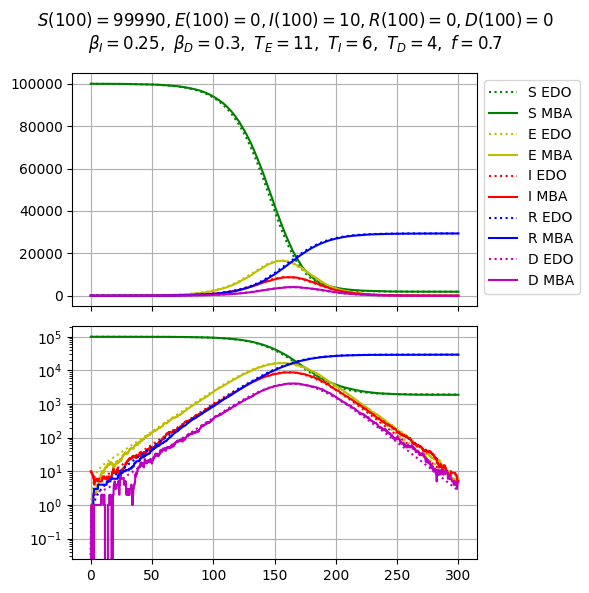

In [5]:
EDOs = modelo_seird(S_i, E_i, I_i, R_i, D_i, 
                        beta_I, beta_D, T_E, T_I, T_D, f, tf, dt)
                        
labels = ['S', 'E', 'I', 'R', 'D']
colors = ['g', 'y', 'r', 'b', 'm']

fig, ax = plt.subplots(2,1, figsize=(6,6), sharex='col', layout='tight')

initial_conditions_label = r'$S(100) = {}, E(100) = {}, I(100) = {}, R(100) = {}, D(100) = {}$'.format(S_i, E_i, I_i, R_i, D_i)
fig.suptitle(initial_conditions_label+'\n'+r'$\beta_{{I}} = {}, \ \beta_{{D}} = {}, \ T_{{E}} = {}, \ T_{{I}} = {}, \ T_{{D}} = {}, \ f = {}$'.format(beta_I, beta_D, T_E, T_I, T_D, f))

for a in ax:
    for i in range(5):
        a.plot(EDOs[0], EDOs[i+1], ls=':',
                    label=labels[i]+' EDO', c=colors[i])
        a.plot(epidemic_series[0], epidemic_series[i+1], 
                    label=labels[i]+' MBA', c=colors[i])
        a.grid()


ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set(yscale='log')

#fig.savefig('mba_vs_edo_serid_shifted.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

## Simulando várias epidemias

### SEIRD_II

In [12]:
# Condições iniciais
N, S_i = 100000, 99990
I_i = N - S_i
II_i, E_i, R_i, D_i = 0, 0, 0, 0
init_conditions = S_i, E_i, I_i, II_i, R_i, D_i

# Parâmetros epidêmicos
# Considerando que taxas de infecção são iguais às taxas de contato per capta 
# multiplicada pela probabilidade de infecção do contato (beta = c * p),
# consideramos que a doença tem um "p" fixo e "c" torna-se o que define "beta"
p = 0.01
c_I, c_II, c_D = 25, 3, 100
beta_I, beta_II, beta_D = np.array([p * c_I]), np.array([p * c_II]), np.array([p * c_D])
T_E, T_I, T_D = np.array([11]), np.array([6]), np.array([4])
alpha, f = np.array([0.2]), np.array([0.7])

dt, tf = 0.1, 400

'''
# Condições iniciais avançadas no tempo
EDOs = modelo_seird(S_i, E_i, I_i, R_i, D_i, beta_I.item(), beta_D.item(), T_E.item(), T_I.item(), T_D.item(), f.item(), tf, dt)
new_initical_cond = [int(EDOs[i][-1]) for i in range(6)]
S_i, E_i, I_i, R_i, D_i = new_initical_cond[1:]
'''

sample_size = 4

params = np.array([[b_I, b_II, b_D, t_E, t_I, a, t_D, fi, n] 
                   for b_I in beta_I for b_II in beta_II for b_D in beta_D for t_E in T_E for t_I in T_I for a in alpha for t_D in T_D for fi in f for n in range(sample_size)],
                    dtype = np.float64)

# Rodar simulações
sims = func_sim_agents('SEIRD_II', init_conditions, params, dt, tf)

100%|██████████| 4000/4000 [00:04<00:00, 811.17it/s] 


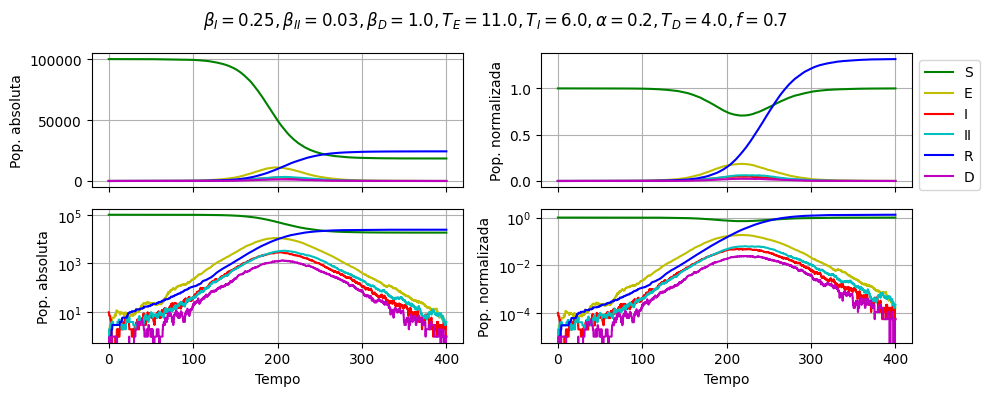

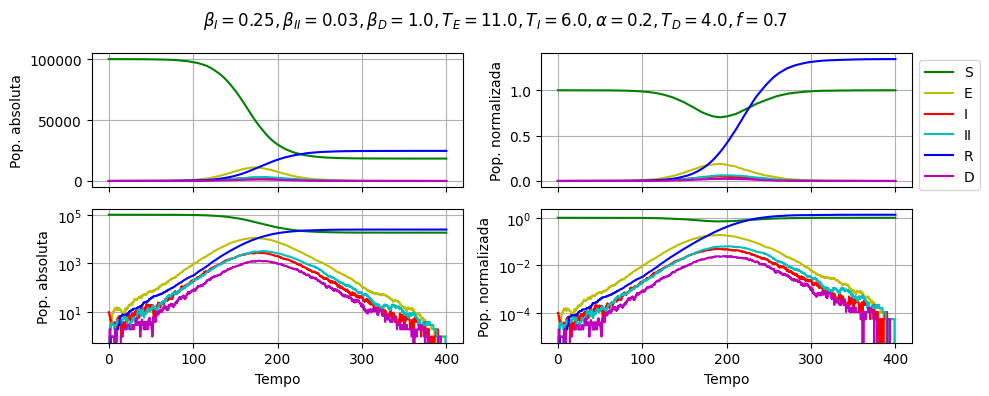

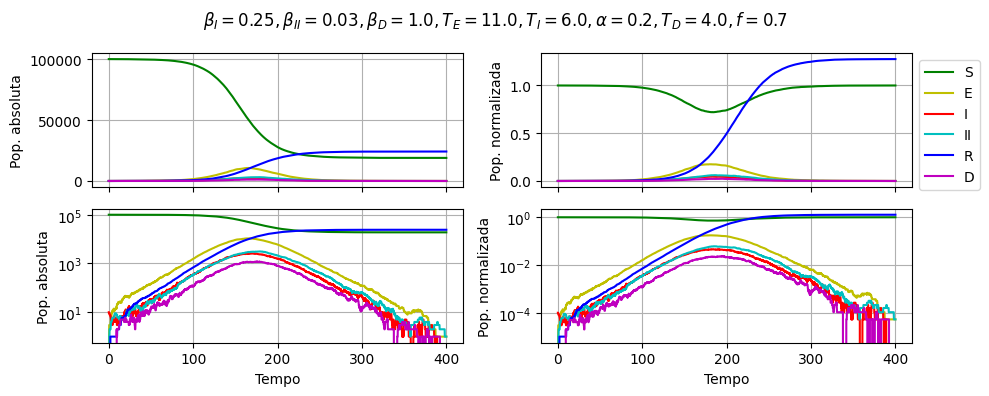

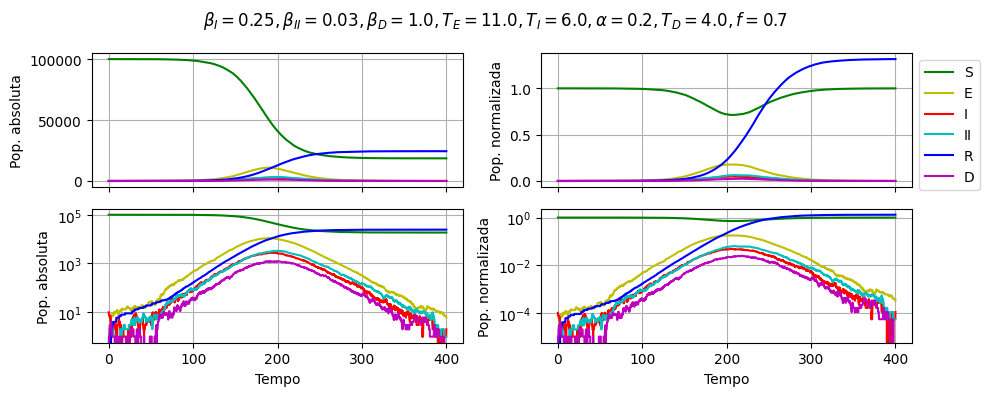

In [14]:
labels = ['S', 'E', 'I', 'II', 'R', 'D']
colors = ['g', 'y', 'r', 'c', 'b', 'm']
tt = np.arange(len(sims[1][0]))*dt

for j in range(len(sims[0])):

    NN = sims[1][j]+sims[2][j]+sims[3][j]+sims[4][j]

    fig, ax = plt.subplots(2,2, figsize=(10,4), sharex='col', layout='tight')

    fig.suptitle(r'$\beta_{{I}} = {}, \beta_{{II}} = {}, \beta_{{D}} = {}, T_{{E}} = {}, T_{{I}} = {}, \alpha = {}, T_{{D}} = {}, f = {}$'.format(*sims[0][j,:-1]))

    for i in range(6):
        ax[0,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[0,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])
        ax[1,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[1,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])

    ax[0,0].set(ylabel = 'Pop. absoluta')
    ax[1,0].set(ylabel = 'Pop. absoluta', xlabel = 'Tempo', yscale='log')
    ax[0,1].set(ylabel = 'Pop. normalizada')
    ax[1,1].set(ylabel = 'Pop. normalizada', xlabel = 'Tempo', yscale='log')

    for a in (ax).flat:
        a.grid()

    ax[0,1].legend(loc='upper left', bbox_to_anchor=(1, 1))   

Comparar média dos resultados do MBA com o resultado do método de Euler

[None]

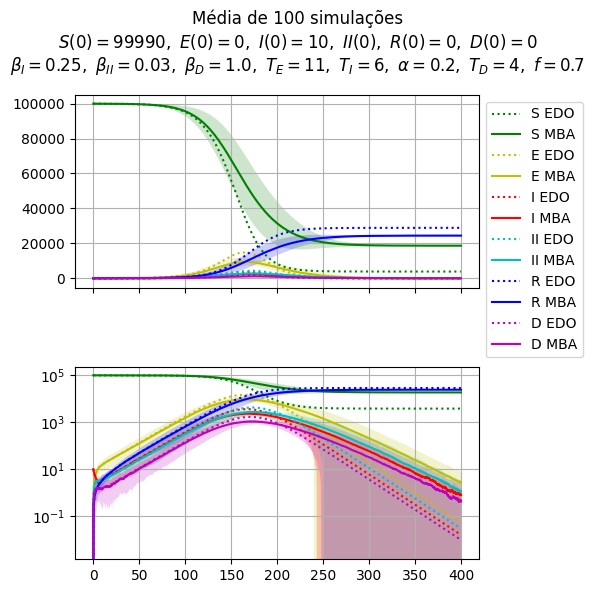

In [88]:
scalar_parameters = beta_I.item(), beta_II.item(), beta_D.item(), T_E.item(), T_I.item(), alpha.item(), T_D.item(), f.item()

EDOs = modelo_seird_ii(S_i, E_i, I_i, II_i, R_i, D_i, 
                    *scalar_parameters, tf, dt)

tt = np.arange(len(sims[1][0]))*dt
                        
labels = ['S', 'E', 'I', 'II', 'R', 'D']
colors = ['g', 'y', 'r', 'c', 'b', 'm']

fig, ax = plt.subplots(2,1, figsize=(6,6), sharex='col', layout='tight')

initial_conditions_label = r'$S(0) = {}, \ E(0) = {}, \ I(0) = {}, \ II(0), \ R(0) = {}, \ D(0) = {}$'.format(S_i, E_i, I_i, II_i, R_i, D_i)
parameters_label = r'$\beta_{{I}} = {}, \ \beta_{{II}} = {}, \ \beta_{{D}} = {}, \ T_{{E}} = {}, \ T_{{I}} = {}, \ \alpha = {}, \ T_{{D}} = {}, \ f = {}$'.format(*scalar_parameters)
fig.suptitle('Média de {} simulações'.format(sample_size)+'\n'+initial_conditions_label+'\n'+parameters_label)

for a in ax:
    for i in range(6):

        mean = np.mean(sims[i+1], axis=0)
        std = np.std(sims[i+1], axis=0)

        a.plot(EDOs[0], EDOs[i+1], ls=':',
                    label=labels[i]+' EDO', c=colors[i])
        a.plot(tt, mean,
                    label=labels[i]+' MBA', c=colors[i])
        a.fill_between(tt, mean-std, mean+std, alpha=0.2, facecolor=colors[i])
        
    a.grid()

ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set(yscale='log')

#fig.savefig('mba_vs_edo_serid_50mean_shifted_fixed.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

### SEIRD

In [17]:
# Condições iniciais
N, S_i = 100000, 99990
I_i = N - S_i
E_i, R_i, D_i = 0, 0, 0
init_conditions = np.array([S_i, E_i, I_i, R_i, D_i])

# Parâmetros epidêmicos
beta_I, beta_D = np.array([0.25]), np.array([0.3])
T_E, T_I, T_D = np.array([11]), np.array([6]), np.array([4])
f = np.array([0.7])

dt, tf = 0.1, 300

'''
# Condições iniciais avançadas no tempo
EDOs = modelo_seird(S_i, E_i, I_i, R_i, D_i, beta_I.item(), beta_D.item(), T_E.item(), T_I.item(), T_D.item(), f.item(), tf, dt)
new_initical_cond = [int(EDOs[i][-1]) for i in range(6)]
S_i, E_i, I_i, R_i, D_i = new_initical_cond[1:]
'''

sample_size = 50

params = np.array([[b_I, b_D, t_E, t_I, t_D, fi, n] 
                   for b_I in beta_I for b_D in beta_D for t_E in T_E for t_I in T_I for t_D in T_D for fi in f for n in range(sample_size)],
                    dtype = np.float64)

# Rodar simulações
sims = func_sim_agents(init_conditions, params, dt, tf)

100%|██████████| 3000/3000 [00:08<00:00, 373.76it/s]


In [ ]:
labels = ['S', 'E', 'I', 'R', 'D']
colors = ['g', 'y', 'r', 'b', 'm']
tt = np.arange(len(sims[1][0]))*dt

for j in range(len(sims[0])):

    NN = sims[1][j]+sims[2][j]+sims[3][j]+sims[4][j]

    fig, ax = plt.subplots(2,2, figsize=(10,4), sharex='col', layout='tight')

    fig.suptitle(r'$\beta_{{I}} = {}, \beta_{{D}} = {}, T_{{E}} = {}, T_{{I}} = {}, T_{{D}} = {}, f = {}$'.format(*sims[0][j,:-1]))

    for i in range(5):
        ax[0,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[0,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])
        ax[1,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[1,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])

    ax[0,0].set(ylabel = 'Pop. absoluta')
    ax[1,0].set(ylabel = 'Pop. absoluta', xlabel = 'Tempo', yscale='log')
    ax[0,1].set(ylabel = 'Pop. normalizada')
    ax[1,1].set(ylabel = 'Pop. normalizada', xlabel = 'Tempo', yscale='log')

    for a in (ax).flat:
        a.grid()

    ax[0,1].legend(loc='upper left', bbox_to_anchor=(1, 1))   

[None]

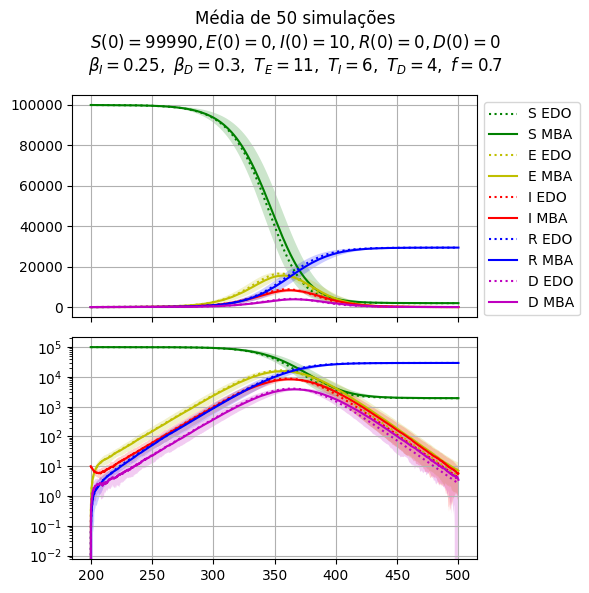

In [16]:
scalar_parameters = beta_I.item(), beta_D.item(), T_E.item(), T_I.item(), T_D.item(), f.item()

EDOs = modelo_seird(S_i, E_i, I_i, R_i, D_i, 
                    *scalar_parameters, tf, dt)

tt = np.arange(len(sims[1][0]))*dt
                        
labels = ['S', 'E', 'I', 'R', 'D']
colors = ['g', 'y', 'r', 'b', 'm']

fig, ax = plt.subplots(2,1, figsize=(6,6), sharex='col', layout='tight')

initial_conditions_label = r'$S(0) = {}, E(0) = {}, I(0) = {}, R(0) = {}, D(0) = {}$'.format(S_i, E_i, I_i, R_i, D_i)
parameters_label = r'$\beta_{{I}} = {}, \ \beta_{{D}} = {}, \ T_{{E}} = {}, \ T_{{I}} = {}, \ T_{{D}} = {}, \ f = {}$'.format(*scalar_parameters)
fig.suptitle('Média de {} simulações'.format(sample_size)+'\n'+initial_conditions_label+'\n'+parameters_label)

for a in ax:
    for i in range(5):

        mean = np.mean(sims[i+1], axis=0)
        std = np.std(sims[i+1], axis=0)

        a.plot(EDOs[0]+200, EDOs[i+1], ls=':',
                    label=labels[i]+' EDO', c=colors[i])
        a.plot(tt+200, mean,
                    label=labels[i]+' MBA', c=colors[i])
        a.fill_between(tt+200, mean-std, mean+std, alpha=0.2, facecolor=colors[i])
        
        a.grid()

ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set(yscale='log')

#fig.savefig('mba_vs_edo_serid_50mean_shifted_fixed.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

In [8]:
sims = abm.func_sim_agents_numba_progressbar(init_conditions, params, dt, tf)

  0%|          | 0/50 [00:00<?, ?it/s]

In [15]:
len(sims)

6

## Salvar e carregar simulações

In [ ]:
# Salvar simulações localmente
save_sim(sim=sims, name='seird_agents_dt01_30mai2026_2', file_format='npz')

# Carregar simulações salvas em csv
#df_sims = pd.read_csv('seird_agents_dt01_28mai2026.csv')

# Carregar e transformar em tupla as simulações salvas em npz
#sims = np.load('seird_agents_dt01_30mai2026.npz')
#sims = tuple(sims[k] for k in sims.keys())